# AI kunskapskontroll 2026 del 2

## EDA

## Börja med att ladda och beskriva data


In [13]:

import numpy as np # För numeriska operationer och arrayhantering
import pandas as pd # För datahantering och analys, särskilt med DataFrames
import matplotlib.pyplot as plt # För att skapa visualiseringar som grafer och diagram
import os # För att hantera filsystemet, t.ex. läsa och skriva filer
import joblib # För att spara och ladda modeller och andra Python-objekt effektivt

from sklearn.datasets import fetch_openml # Util lib För att hämta öppna datamängder, t.ex. MNIST
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,            # Total balanserad mått på hurpass korrekt modellen är vilket är TP+TN/Total
    precision_score,           # Hurpass korrekta är de positiva förutsägelserna, vilket är TP/TP+FP
    recall_score,              # Hurpass korrekta är de faktiska positiva förutsägelserna, vilket är TP/TP+FN
    f1_score,                  # Harmoniskt medelvärde av precision och recall
    classification_report,     # Textsammanfattning av precision/recall/F1/support per klass
    ConfusionMatrixDisplay,    # Verktyg för att visualisera förväxlingsmatrisens räkningar
    log_loss,                  # Straffar felaktigt förutsagda sannolikheter (lägre är bättre)
    top_k_accuracy_score,      # Sann etikett finns i modellens topp-k förutsägelser
    balanced_accuracy_score,   # Genomsnittlig recall över klasser (hanterar obalans bättre)
 )


In [ ]:


# Externaliserar funktioner för att det ska var enkla att följa röda tråden

def load_mnist():
    "Ladda Mnist, ""Load MNIST, print description and shape, return (X, y) with integer labels."""
    mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
    print(mnist.DESCR)
    print("Shape:", mnist.data.shape)
    return mnist.data, mnist.target.astype(int)


def plot_class_distribution(y, title="Klassfördelning"):
    """Bar chart of class counts."""
    pd.Series(y).value_counts().sort_index().plot(kind="bar")
    plt.title(title)
    plt.show()


def plot_pixel_distribution(X, title="Pixelintensitetsfördelning", bins=50):
    """Histogram of pixel intensities."""
    plt.hist(X.flatten(), bins=bins)
    plt.title(title)
    plt.show()


def plot_average_digits(X, y):
    """Show mean image for each unique class label."""
    for digit in np.unique(y):
        plt.imshow(X[y == digit].mean(axis=0).reshape(28, 28), cmap="gray")
        plt.title(f"Genomsnittlig siffra {digit}")
        plt.show()


def prepare_data(X, y, scale=True, test_size=0.2, random_state=42):
    """Optionally scale and split into train/test sets."""
    X_proc = X / 255.0 if scale else X
    return train_test_split(X_proc, y, test_size=test_size, random_state=random_state)


def train_logistic_regression(X_train, y_train, max_iter=1000):
    """Train and return a LogisticRegression model."""
    model = LogisticRegression(max_iter=max_iter)
    model.fit(X_train, y_train)
    return model


def train_or_load_svc(X_train, y_train, model_path='mnist_svc_model.joblib', kernel='rbf'):
    """Load SVC from disk if available, otherwise train and save it."""
    if os.path.exists(model_path):
        print("Loading SVC model from file...")
        return joblib.load(model_path)
    print("Training SVC model...")
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    
    # det har visat sig att SVC tar väldigt lång tid att träna, så vi sparar modellen på disk
    joblib.dump(model, model_path)
    print("SVC model saved to file.")
    return model


def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    """Build, compile and return a CNN model."""
    from tensorflow import keras
    from tensorflow.keras import layers
    model = keras.Sequential([
        #Efter varje conv, pool, flatten, dense så minskar "upplösningen" av datan, men den blir mer "abstrakt" och "meningsfull" för klassificering
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape), #huvudbygsten i CNN, lär sig 32 små filter som skannar över bilden och letar efter mönster
        layers.MaxPooling2D(pool_size=(2, 2)), # MaxPooling2D minskar bildens dimensioner genom att ta det maximala värdet i varje 2x2-block, vilket hjälper till att minska överanpassning och förbättra generalisering
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'), #TODO: andra conv lager är en canidate för borttagning om tiden blir för lång. Mät total tid i slutet!
        layers.MaxPooling2D(pool_size=(2, 2)), # TODO: andra maxpooling är en canidate för borttagning om tiden blir för lång. Mät total tid i slutet!
        layers.Flatten(), # Flatten omvandlar den 2D-utdata från konvolutionslagren till en 1D-vektor som kan matas in i de tätt anslutna lagren
        layers.Dropout(0.5), # Dropout är en regulariseringsteknik som slumpmässigt "stänger av" en del av neuronerna under träning, vilket hjälper till att minska överanpassning
        layers.Dense(128, activation='relu'), #TODO: testa ta bort den och lägg märke till accuracy ändring. # Dense lager med 128 neuroner och ReLU-aktivering fungerar som ett "fullt anslutet" lager för att lära sig mer komplexa representationer
        layers.Dense(num_classes, activation='softmax') #TODO: testa ändra till 'sigmoid' # dense med softmax-aktivering i sista lagret används för att få sannolikheter för varje klass, vilket är viktigt för multi-class klassificering.
        # Jag valde softmax eftersom det är standard för multi-class klassificering, och mnist är en multi-class klassificering där varje bild bara tillhör en klass, så 'sigmoid' skulle inte vara lämpligt här.
    ], name="Mnist_CNN")
    # TODO: testa one-hot encoding av y och använd 'categorical_crossentropy' istället för 'sparse_categorical_crossentropy' i compile, och se om det gör någon skillnad i accuracy. Det kan vara värt att testa eftersom det ibland kan ge bättre resultat
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # sparse_categorical_crossentropy används när y är i form av heltal (inte one-hot encoded) och det är en multi-class klassificering
    model.summary()
    return model


#
def train_cnn(model, X_train, y_train, image_shape=(28, 28, 1), epochs=10, batch_size=128, validation_split=0.2):
    """Reshape X_train and fit the CNN. Returns (history, X_train_reshaped)."""
    X_reshaped = X_train.reshape(-1, *image_shape)
    history = model.fit(X_reshaped, y_train, epochs=epochs, batch_size=batch_size,
                        validation_split=validation_split, verbose=1)
    return history, X_reshaped


def evaluate_predictions(y_true, y_pred, name, y_proba=None):
    """Compute and print a unified set of metrics for any classifier. Uses English terminology."""
    scores = {
        "modell": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if y_proba is not None:
        labels = np.unique(y_true)
        scores["log_loss"] = log_loss(y_true, y_proba, labels=labels)
        scores["top_3_accuracy"] = top_k_accuracy_score(y_true, y_proba, k=3, labels=labels)

    print(f"\n=== {name} ===")
    for key in ["accuracy", "f1_macro", "f1_weighted", "balanced_accuracy"]:
        print(f"{key}: {scores[key]:.4f}")
    if y_proba is not None:
        for key in ["log_loss", "top_3_accuracy"]:
            print(f"{key}: {scores[key]:.4f}")

    print("\nKlassificeringsrapport:")
    print(classification_report(y_true, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues", values_format="d")
    plt.title(f"Förvirringsmatris - {name}")
    plt.show()

    return scores


def evaluate_sklearn_model(model, X_test, y_test, name):
    """Evaluate sklearn model with unified metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    return evaluate_predictions(y_test, y_pred, name, y_proba=y_proba)


def evaluate_cnn(model, X_test, y_test, image_shape=(28, 28, 1), name="CNN"):
    """Evaluate CNN model with same metrics as sklearn models."""
    X_reshaped = X_test.reshape(-1, *image_shape)
    y_proba = model.predict(X_reshaped, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    return evaluate_predictions(y_test, y_pred, name, y_proba=y_proba)


In [15]:
def evaluate_overfitting_sklearn(model, X_train, y_train, X_test, y_test, name):
    """Compare train vs test metrics to estimate overfitting for sklearn models. Uses English terminology."""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    gap_acc = train_acc - test_acc
    gap_f1 = train_f1 - test_f1

    print(f"\n=== Överanpassningskontroll: {name} ===")
    print(f"train_accuracy: {train_acc:.4f} | test_accuracy: {test_acc:.4f} | gap: {gap_acc:.4f}")
    print(f"train_f1_macro: {train_f1:.4f} | test_f1_macro: {test_f1:.4f} | gap: {gap_f1:.4f}")

    return {
        "modell": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "gap_accuracy": gap_acc,
        "train_f1_macro": train_f1,
        "test_f1_macro": test_f1,
        "gap_f1_macro": gap_f1,
    }


def evaluate_overfitting_cnn(history, name="CNN"):
    """Inspect train/validation curves and final metric gaps for CNN. Uses English terminology."""
    hist = history.history
    train_acc = hist.get("accuracy", [])
    val_acc = hist.get("val_accuracy", [])
    train_loss = hist.get("loss", [])
    val_loss = hist.get("val_loss", [])

    if train_acc and val_acc:
        acc_gap = train_acc[-1] - val_acc[-1]
    else:
        acc_gap = np.nan

    if train_loss and val_loss:
        loss_gap = val_loss[-1] - train_loss[-1]
    else:
        loss_gap = np.nan

    print(f"\n=== Överanpassningskontroll: {name} ===")
    if train_acc and val_acc:
        print(
            f"final_train_accuracy: {train_acc[-1]:.4f} | final_val_accuracy: {val_acc[-1]:.4f} | gap: {acc_gap:.4f}"
        )
    if train_loss and val_loss:
        print(
            f"final_train_loss: {train_loss[-1]:.4f} | final_val_loss: {val_loss[-1]:.4f} | gap: {loss_gap:.4f}"
        )

    if train_acc and val_acc and train_loss and val_loss:
        epochs = range(1, len(train_acc) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(epochs, train_acc, label="Träning accuracy")
        axes[0].plot(epochs, val_acc, label="Validering accuracy")
        axes[0].set_title(f"{name} accuracy kurva")
        axes[0].set_xlabel("Epok")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()

        axes[1].plot(epochs, train_loss, label="Träning loss")
        axes[1].plot(epochs, val_loss, label="Validering loss")
        axes[1].set_title(f"{name} loss kurva")
        axes[1].set_xlabel("Epok")
        axes[1].set_ylabel("Loss")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return {
        "modell": name,
        "train_accuracy": train_acc[-1] if train_acc else np.nan,
        "test_accuracy": np.nan,
        "gap_accuracy": acc_gap,
        "train_f1_macro": np.nan,
        "test_f1_macro": np.nan,
        "gap_f1_macro": np.nan,
        "train_loss": train_loss[-1] if train_loss else np.nan,
        "val_loss": val_loss[-1] if val_loss else np.nan,
        "gap_loss": loss_gap,
    }


In [16]:
X, y = load_mnist()


**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

## Är all data balanserad?


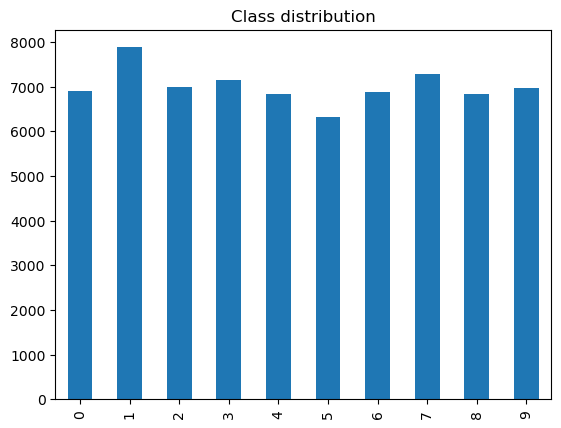

In [17]:
plot_class_distribution(y) # hur många bilder finns det av varje siffra? Är datasetet balanserat?


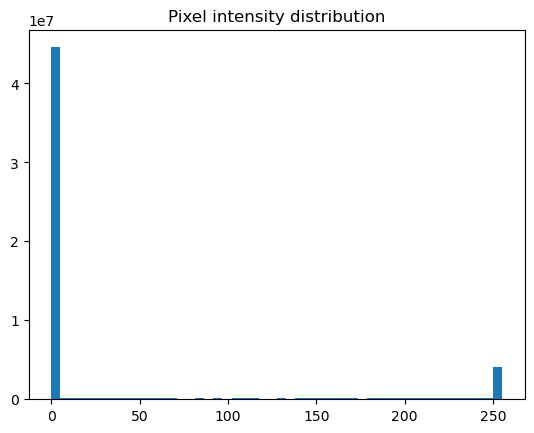

In [18]:
plot_pixel_distribution(X) # hur många pixlar för alla bilder


## Visualisera alla. Genomsnittlig bild per siffra


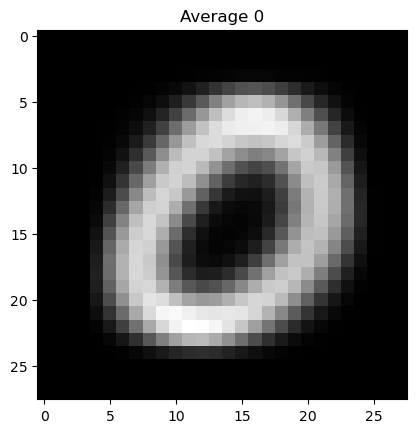

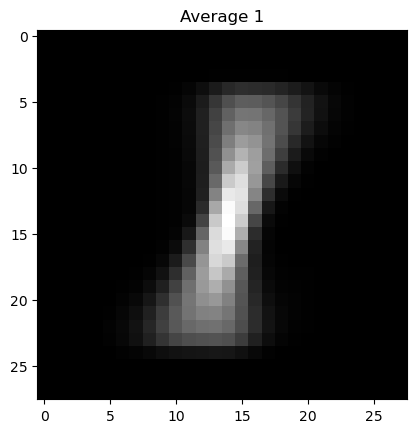

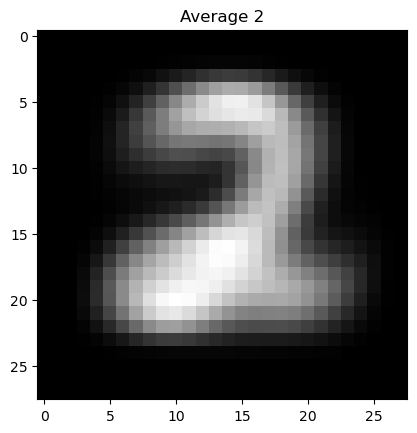

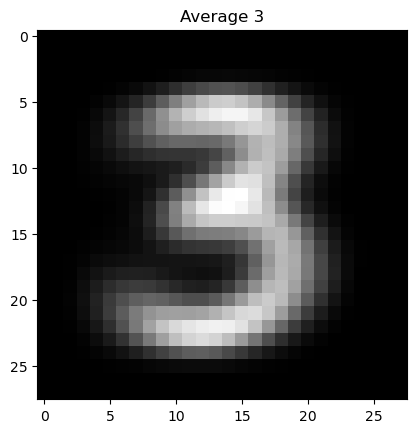

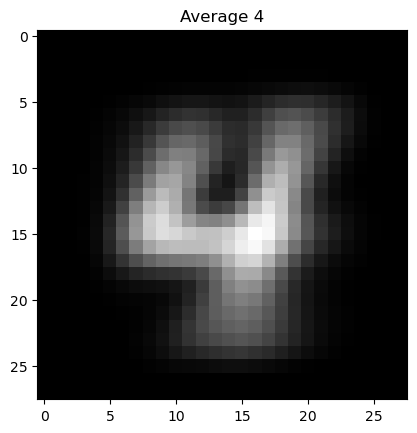

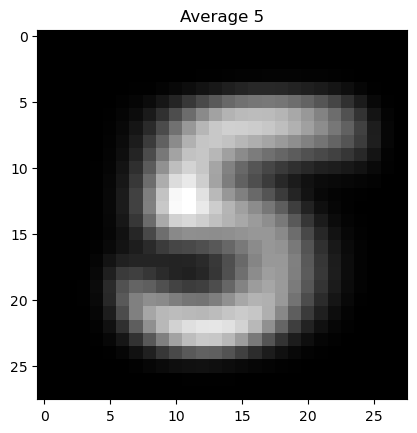

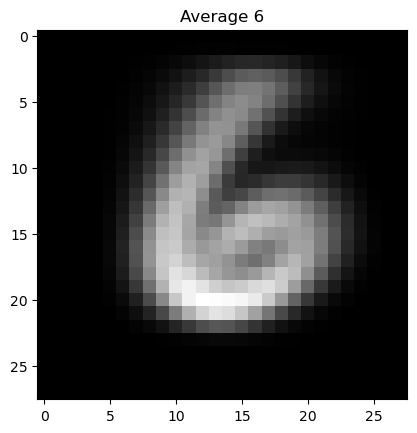

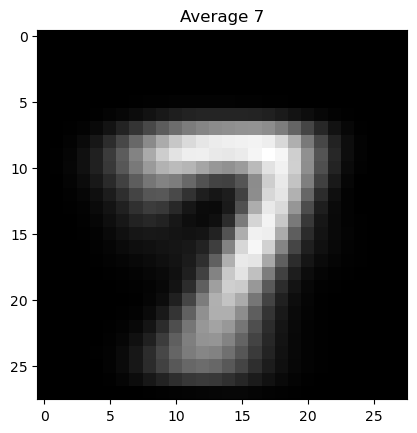

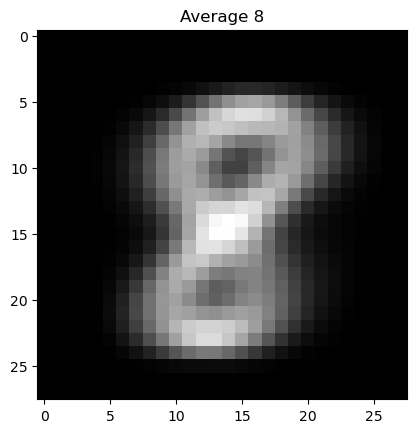

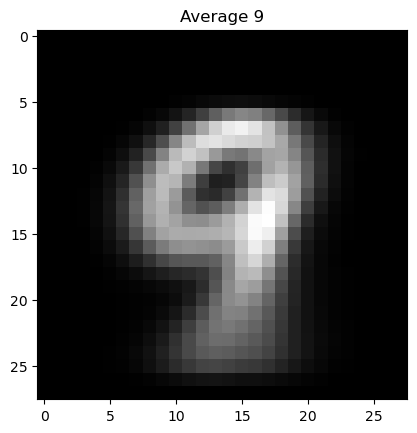

In [19]:
plot_average_digits(X, y) # Genomsnittlig bild för varje siffra, visar typiska mönster och variationer inom klasserna. Algoritmen är vanlig asimetrisk medelberäkning.


## Dela upp data i träning, validering, test


In [20]:
X_train, X_test, y_train, y_test = prepare_data(X, y)


## Steg Träning:


In [21]:
linreg_model = train_logistic_regression(X_train, y_train)
svc_model = train_or_load_svc(X_train, y_train)


Loading SVC model from file...


### Om modellnamn i Keras-sammanfattning
Här kallar vi vår cnn modell explicit för "Mnist_CNN", för att undvika namn som "sequential_1", som det kommer att heta om vi låter bli sätta namn på den.

Hur man läser sammanfattningstabellen:
- Lager (typ): varje operation i nätverket, såsom Conv2D, MaxPooling2D, Flatten, Dense.
- Output Shape: tensorformen efter det lagret.
- Param #: antal träningsbara parametrar i lagret.
- Totala parametrar / Träningsbara parametrar: modellens kapacitet och vad som uppdateras under träning.

Denna tabell förklarar arkitekturens storlek/komplexitet, medan förvirringsmatrisen och F1/noggrannhet förklarar prediktionskvaliteten.


In [22]:
%pip install tensorflow -q
import tensorflow as tf

model_cnn = build_cnn()
history, X_train_cnn = train_cnn(model_cnn, X_train, y_train)


Note: you may need to restart the kernel to use updated packages.


c:\Users\alexa\.conda\envs\CondaPython3_13_lab12\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Mnist_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9162 - loss: 0.2822 - val_accuracy: 0.9763 - val_loss: 0.0774
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9728 - loss: 0.0858 - val_accuracy: 0.9837 - val_loss: 0.0513
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9802 - loss: 0.0640 - val_accuracy: 0.9861 - val_loss: 0.0421
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9832 - loss: 0.0537 - val_accuracy: 0.9881 - val_loss: 0.0382
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9858 - loss: 0.0443 - val_accuracy: 0.9889 - val_loss: 0.0376
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9865 - loss: 0.0404 - val_accuracy: 0.9882 - val_loss: 0.0363
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9885 - loss: 0.0356 - val_accuracy: 0.9904 - val_loss: 0.0305
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9896 - loss: 0.0318 - val_accu

## Steg Utvärdering:



=== Logistic Regression ===
accuracy: 0.9201
f1_macro: 0.9191
f1_weighted: 0.9199
balanced_accuracy: 0.9190
log_loss: 0.2963
top_3_accuracy: 0.9839

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.95      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



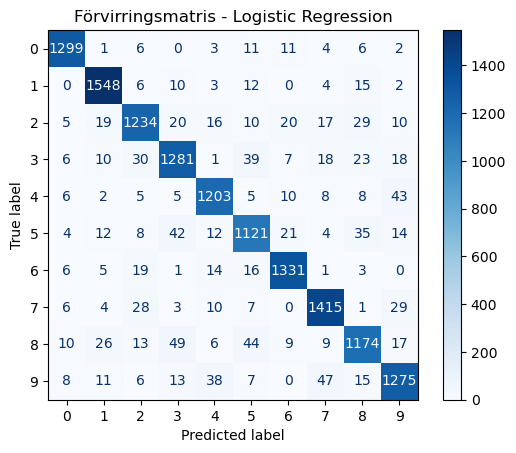


=== SVC ===
accuracy: 0.9764
f1_macro: 0.9763
f1_weighted: 0.9764
balanced_accuracy: 0.9763

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.98      0.99      0.99      1600
           2       0.97      0.98      0.97      1380
           3       0.97      0.97      0.97      1433
           4       0.97      0.98      0.98      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.97      0.97      0.97      1503
           8       0.97      0.96      0.97      1357
           9       0.97      0.96      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



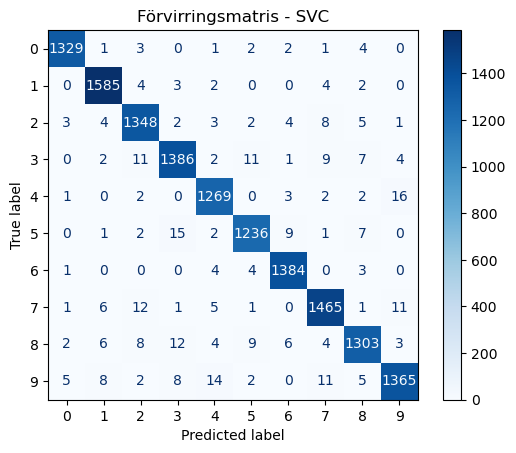


=== CNN ===
accuracy: 0.9909
f1_macro: 0.9909
f1_weighted: 0.9909
balanced_accuracy: 0.9910
log_loss: 0.0285
top_3_accuracy: 0.9995

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      0.99      0.99      1600
           2       0.99      0.99      0.99      1380
           3       1.00      0.99      0.99      1433
           4       0.99      0.99      0.99      1295
           5       0.99      0.99      0.99      1273
           6       0.99      1.00      0.99      1396
           7       0.99      0.99      0.99      1503
           8       0.98      0.99      0.99      1357
           9       0.99      0.99      0.99      1420

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



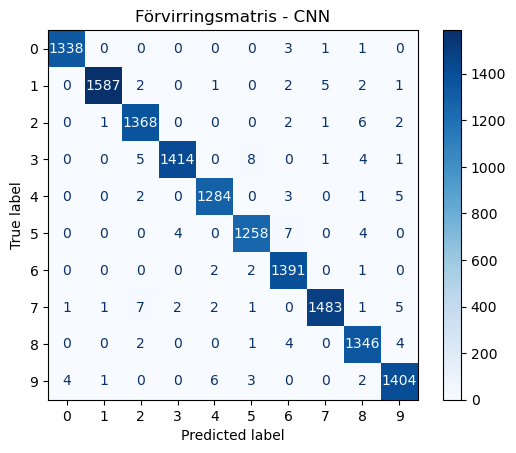

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,log_loss,top_3_accuracy
modell,,,,,,,,
CNN,0.990929,0.990966,0.990792,0.990966,0.990869,0.990932,0.028472,0.999500
SVC,0.976429,0.976267,0.976361,0.976267,0.976296,0.976407,NaN,NaN
Logistic Regression,0.920071,0.919034,0.919240,0.919034,0.919076,0.919885,0.296250,0.983857


In [23]:
scores_lr = evaluate_sklearn_model(linreg_model, X_test, y_test, "Logistic Regression")
scores_svc = evaluate_sklearn_model(svc_model, X_test, y_test, "SVC")
scores_cnn = evaluate_cnn(model_cnn, X_test, y_test, name="CNN")

comparison_df = pd.DataFrame([scores_lr, scores_svc, scores_cnn]).set_index("modell")
display(comparison_df.sort_values("f1_macro", ascending=False))


In [ ]:
overfit_lr = evaluate_overfitting_sklearn(
    linreg_model, X_train, y_train, X_test, y_test, "Logistic Regression"
 )
overfit_svc = evaluate_overfitting_sklearn(
    svc_model, X_train, y_train, X_test, y_test, "SVC"
 )
overfit_cnn = evaluate_overfitting_cnn(history, name="CNN")

overfit_df = pd.DataFrame([overfit_lr, overfit_svc, overfit_cnn]).set_index("modell")
display(overfit_df)



=== Överanpassningskontroll: Logistic Regression ===
train_accuracy: 0.9390 | test_accuracy: 0.9201 | gap: 0.0189
train_f1_macro: 0.9382 | test_f1_macro: 0.9191 | gap: 0.0191


## Överanpassningsdiagnostik
En modell kan se bra ut på testmått men ändå vara överanpassad.
Vi jämför därför träningsprestation mot test/valideringsprestation:
- För sklearn-modeller: train-vs-test accuracy och F1 macro gaps.
- För CNN: train-vs-validation accuracy/loss kurvor och slutliga gaps.

Tumregel:
- Små gaps indikerar bra generalisering.
- Stora positiva train-minus-test/train-minus-val gaps indikerar överanpassning.
